<a href="https://colab.research.google.com/github/aniolarolas/quant-research-pricing-credit-risk/blob/main/notebooks/03_credit_risk_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 3: Credit Risk Modelling and Expected Loss

## 1. Problem Understanding

The objective of this task is to build a model that estimates the probability that a borrower will default on a loan.

The dataset contains borrower-level information, including income, outstanding loan amount, total debt, years employed, FICO score, number of credit lines outstanding, and whether the borrower has previously defaulted.

The model should estimate the probability of default, also known as PD. This probability can then be used to calculate the expected loss of a loan.

The expected loss is defined as:

$$
Expected\ Loss = PD \times LGD \times EAD
$$

where:

- \(PD\) is the probability of default,
- \(LGD\) is the loss given default,
- \(EAD\) is the exposure at default.

The task states that the recovery rate is 10%. Therefore:

$$
LGD = 1 - Recovery\ Rate = 1 - 0.10 = 0.90
$$

In this notebook, we will train a Random Forest classifier to estimate the probability of default and then use that probability to calculate the expected loss for a given borrower.

## 2. Financial Background

Credit risk is the risk that a borrower fails to meet their debt obligations. In this task, default is represented as a binary outcome: either the borrower defaults or they do not.

A credit risk model does not only classify borrowers as risky or safe. More importantly, it estimates the probability of default. This probability allows the lender to quantify the expected loss associated with a loan.

Expected loss combines three components:

- **Probability of Default (PD):** the likelihood that the borrower defaults.
- **Loss Given Default (LGD):** the proportion of the exposure that is lost if default occurs.
- **Exposure at Default (EAD):** the amount outstanding when default occurs.

In this prototype, the outstanding loan amount is used as the exposure at default. Since the recovery rate is assumed to be 10%, the loss given default is 90%.

## 3. Data Loading

We start by loading the loan dataset and inspecting its structure. The dataset contains borrower-level information and a binary target variable called `default`, which indicates whether the borrower has previously defaulted.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df = pd.read_csv("/content/drive/MyDrive/quant_research_jpm_jobsim/data/raw/Task 3 and 4_Loan_Data.csv")

Basic inspection of data

In [3]:
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [5]:
df.describe().map(lambda x: f"{x:,.2f}")

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,"10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00"
mean,"4,974,577.00",1.46,"4,159.68","8,718.92","70,039.90",4.55,637.56,0.19
std,"2,293,889.71",1.74,"1,421.40","6,627.16","20,072.21",1.57,60.66,0.39
min,"1,000,324.00",0.00,46.78,31.65,"1,000.00",0.00,408.00,0.00
25%,"2,977,661.00",0.00,"3,154.24","4,199.84","56,539.87",3.00,597.00,0.00
50%,"4,989,501.50",1.00,"4,052.38","6,732.41","70,085.83",5.00,638.00,0.00
75%,"6,967,210.25",2.00,"5,052.90","11,272.26","83,429.17",6.00,679.00,0.00
max,"8,999,789.00",5.00,"10,750.68","43,688.78","148,412.18",10.00,850.00,1.00


In [6]:
df.isnull().sum()

,0
customer_id,0
credit_lines_outstanding,0
loan_amt_outstanding,0
total_debt_outstanding,0
income,0
years_employed,0
fico_score,0
default,0


In [7]:
df["default"].value_counts()

,count
default,
0,8149
1,1851


In [8]:
df["default"].value_counts(normalize=True)

,proportion
default,
0,0.8149
1,0.1851


The dataset contains numerical borrower characteristics and a binary default indicator. Before training the model, we check the size of the dataset, the available features, missing values, and the distribution of the target variable.

## 4. Exploratory Data Analysis

Before training the model, we explore the relationship between borrower characteristics and default risk.

The goal is to understand whether variables such as FICO score, income, debt, years employed, outstanding loan amount, and credit lines outstanding show meaningful differences between borrowers who defaulted and borrowers who did not.

Target distribution

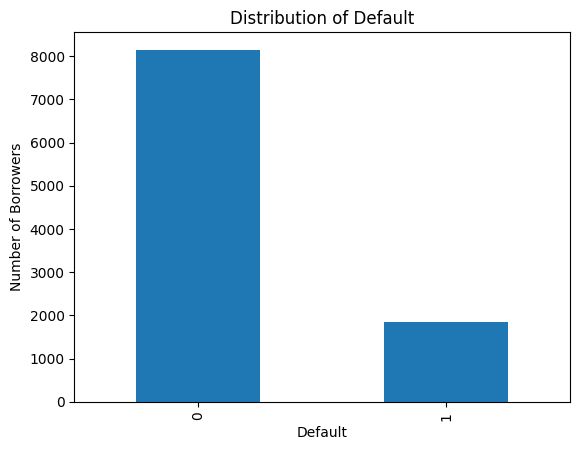

In [9]:
df["default"].value_counts().plot(kind="bar")

plt.xlabel("Default")
plt.ylabel("Number of Borrowers")
plt.title("Distribution of Default")
plt.show()

Mean by group

In [10]:
df.groupby("default").mean(numeric_only=True).map(lambda x: f"{x:,.2f}")

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score
default,,,,,,,
0,"4,967,004.75",0.74,"4,092.63","6,322.16","69,883.89",4.77,646.94
1,"5,007,913.70",4.62,"4,454.85","19,270.58","70,726.74",3.62,596.26


Plots for each variable

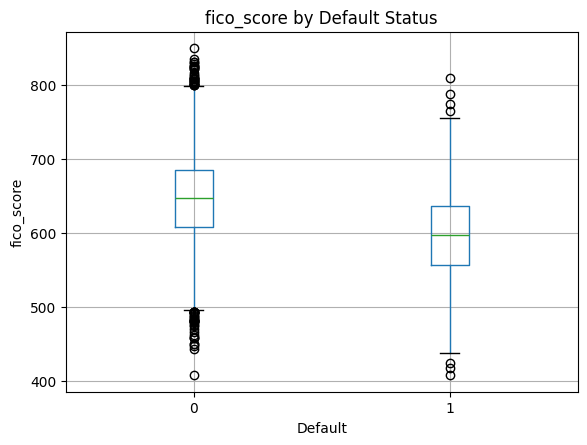

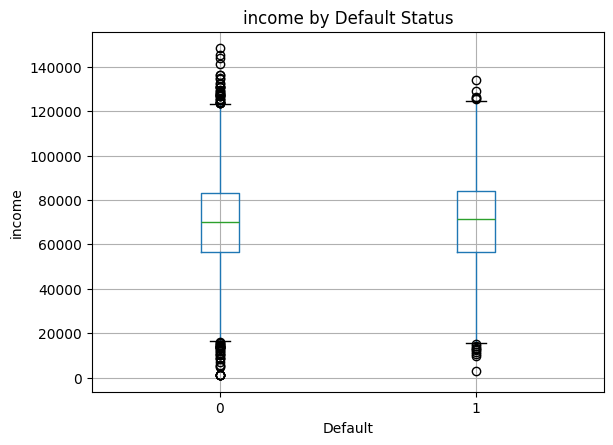

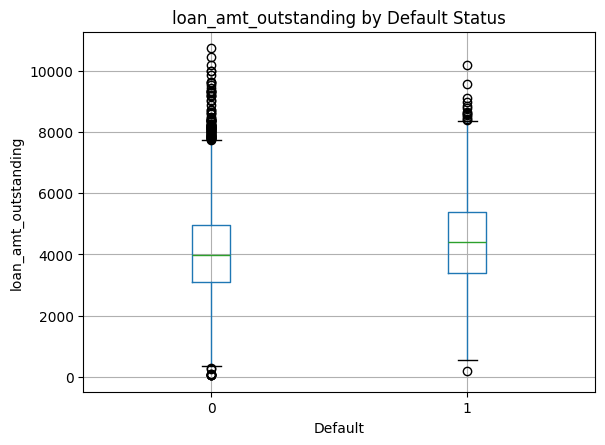

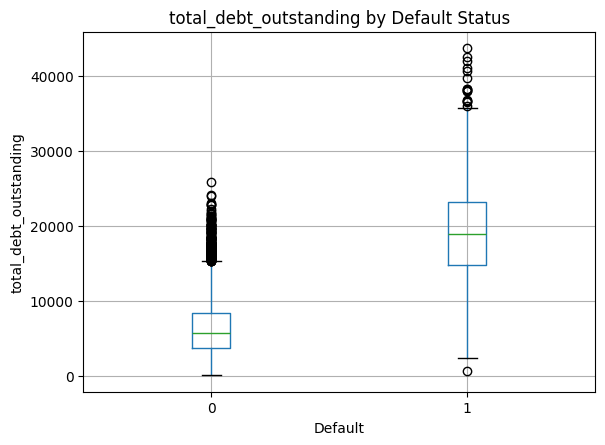

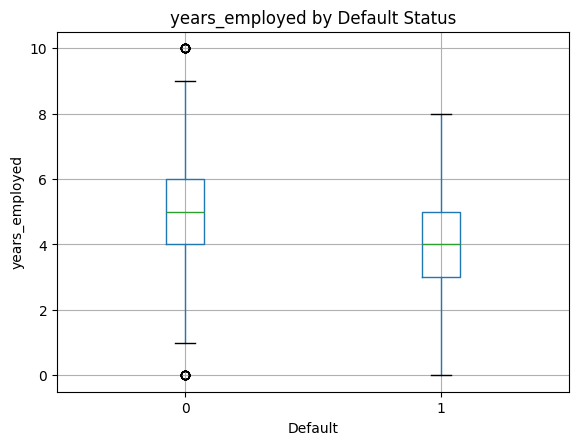

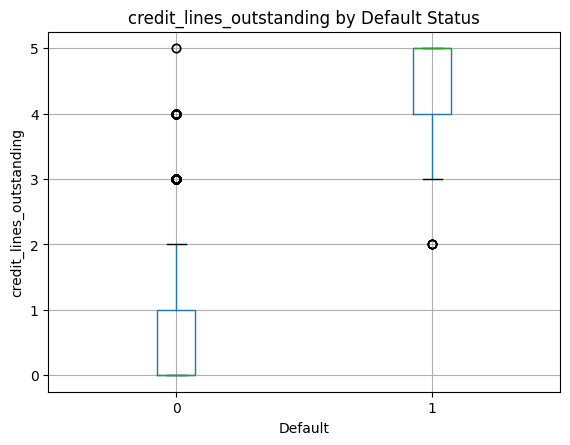

In [11]:
features_to_plot = [
    "fico_score",
    "income",
    "loan_amt_outstanding",
    "total_debt_outstanding",
    "years_employed",
    "credit_lines_outstanding"
]

for feature in features_to_plot:
    df.boxplot(column=feature, by="default")
    plt.title(f"{feature} by Default Status")
    plt.suptitle("")
    plt.xlabel("Default")
    plt.ylabel(feature)
    plt.show()

### Correlation between variables and default
As an initial exploratory step, we compute the correlation between each numerical feature and the default indicator. Since `default` is encoded as 0 for non-default and 1 for default, positive correlations suggest variables associated with higher default risk, while negative correlations suggest variables associated with lower default risk. This analysis is only used as a preliminary diagnostic, since correlation does not capture non-linear relationships or interactions between variables.

In [12]:
correlation = df.corr(numeric_only=True)

correlation["default"].sort_values(ascending=False)

,default
default,1.000000
credit_lines_outstanding,0.862815
total_debt_outstanding,0.758868
loan_amt_outstanding,0.098978
income,0.016309
customer_id,0.006927
years_employed,-0.284506
fico_score,-0.324515


## 5. Feature Selection and Train/Test Split

The model will use borrower characteristics as input features and the `default` column as the target variable.

The selected features are:

- `credit_lines_outstanding`
- `loan_amt_outstanding`
- `total_debt_outstanding`
- `income`
- `years_employed`
- `fico_score`

The target variable is:

- `default`

The dataset is split into training and testing sets. The training set is used to fit the model, while the test set is used to evaluate how well the model generalizes to unseen borrowers.

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
features = [
    "credit_lines_outstanding",
    "loan_amt_outstanding",
    "total_debt_outstanding",
    "income",
    "years_employed",
    "fico_score"
]

X = df[features]
y = df["default"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 6)
X_test shape: (2000, 6)
y_train shape: (8000,)
y_test shape: (2000,)


The dataset is split into 80% training data and 20% test data. The training set is used to fit the models, while the test set is kept separate to evaluate performance on borrowers that the models have not seen during training.

The split is stratified by the target variable to preserve the proportion of default and non-default observations in both sets.

## 6. Model Training

Two models are trained in this section.

First, a Logistic Regression model is used as a simple and interpretable baseline. Logistic regression is commonly used in credit risk because it provides direct probability estimates and is easy to explain.

Second, a Random Forest classifier is trained as the main model. Random Forest can capture non-linear relationships and interactions between borrower characteristics, making it more flexible than a linear model.

Both models are trained on the same training set and will later be evaluated on the same test set.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

### Logistic Regression

In [18]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

### Random forest

In [19]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

random_forest_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       min_samples_split=10, n_estimators=300, random_state=42)

In [20]:
logistic_pd = logistic_model.predict_proba(X_test)[:, 1]
random_forest_pd = random_forest_model.predict_proba(X_test)[:, 1]

print(logistic_pd[:5])
print(random_forest_pd[:5])

[8.68464675e-14 2.54184461e-04 1.95714179e-09 2.99362896e-10
 3.98829286e-10]
[0.         0.02489218 0.0044555  0.         0.        ]


## 7. Model Evaluation

After training the Logistic Regression and Random Forest models, we evaluate their performance on the test set.

In credit risk modelling, we are especially interested in the quality of the predicted probabilities of default. A useful model should assign higher probabilities to borrowers who are more likely to default and lower probabilities to safer borrowers.

We compare the models using:

- ROC-AUC,
- confusion matrix,
- classification report,
- probability distributions,
- model interpretability outputs.

### 7.2 ROC-AUC Curve

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

In [22]:
logistic_pd = logistic_model.predict_proba(X_test)[:, 1]
random_forest_pd = random_forest_model.predict_proba(X_test)[:, 1]

logistic_auc = roc_auc_score(y_test, logistic_pd)
random_forest_auc = roc_auc_score(y_test, random_forest_pd)

print("Logistic Regression AUC:", logistic_auc)
print("Random Forest AUC:", random_forest_auc)

Logistic Regression AUC: 0.9999883933012768
Random Forest AUC: 0.9998093185209749


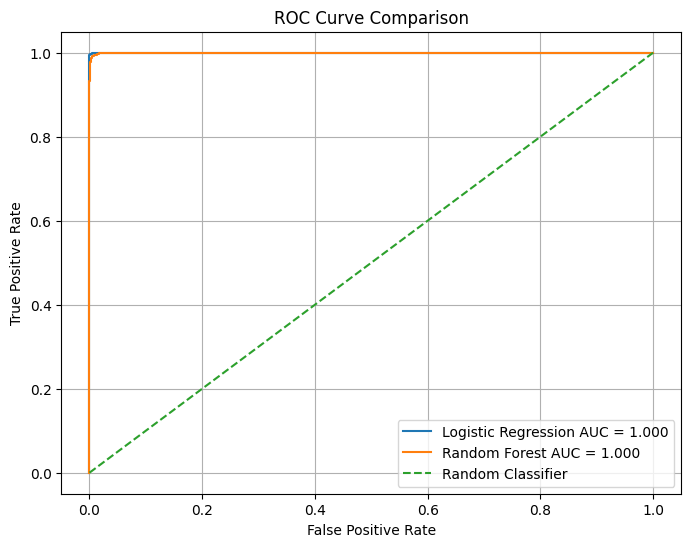

In [23]:
logistic_fpr, logistic_tpr, _ = roc_curve(y_test, logistic_pd)
rf_fpr, rf_tpr, _ = roc_curve(y_test, random_forest_pd)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression AUC = {logistic_auc:.3f}"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest AUC = {random_forest_auc:.3f}"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

The ROC curve compares how well each model separates defaulted borrowers from non-defaulted borrowers across different classification thresholds.

The AUC summarizes this performance in a single number. An AUC close to 1 indicates strong discriminatory power, while an AUC close to 0.5 indicates performance similar to random classification.

### 7.2 Confusion Matrix and Classification Report

The ROC-AUC evaluates the ranking quality of predicted probabilities. However, it is also useful to inspect the classification results using a fixed probability threshold.

Using a threshold of 0.5, borrowers with predicted probability of default greater than or equal to 0.5 are classified as defaulted borrowers.

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [25]:
logistic_pred = (logistic_pd >= 0.5).astype(int)
random_forest_pred = (random_forest_pd >= 0.5).astype(int)

Confusion matrix Logistic Regression:

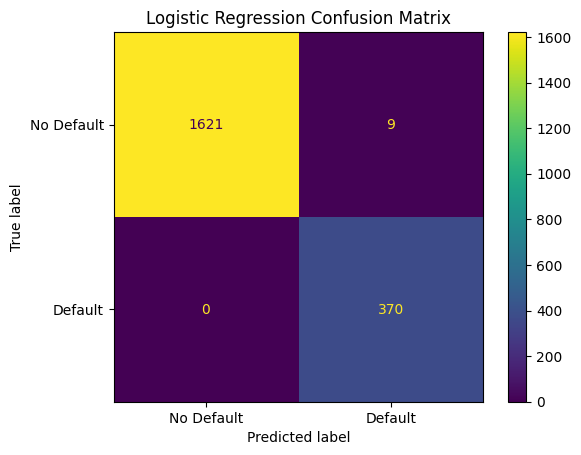

In [26]:
cm_logistic = confusion_matrix(y_test, logistic_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["No Default", "Default"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Confusion matrix Random Forest:

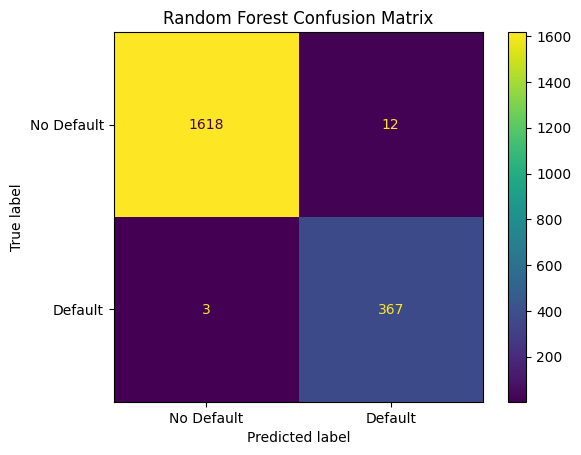

In [27]:
cm_rf = confusion_matrix(y_test, random_forest_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Default", "Default"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [28]:
print("Logistic Regression Classification Report")
print(classification_report(y_test, logistic_pred))

print("Random Forest Classification Report")
print(classification_report(y_test, random_forest_pred))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1630
           1       0.98      1.00      0.99       370

    accuracy                           1.00      2000
   macro avg       0.99      1.00      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Random Forest Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1630
           1       0.97      0.99      0.98       370

    accuracy                           0.99      2000
   macro avg       0.98      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



The confusion matrix shows how many borrowers are correctly and incorrectly classified as default or non-default. The classification report provides precision, recall, and F1-score for each class.

In credit risk, recall for the default class is especially important because missing a borrower who later defaults can lead to financial losses. However, this must be balanced against false positives, where safe borrowers are incorrectly classified as risky.

### 7.3 Predicted Probability Distribution

Since the objective is to estimate probability of default, it is useful to inspect the distribution of predicted probabilities produced by each model.

A good credit risk model should assign lower probabilities to safer borrowers and higher probabilities to riskier borrowers. Comparing the probability distributions helps us understand whether the models produce reasonable and differentiated risk scores.

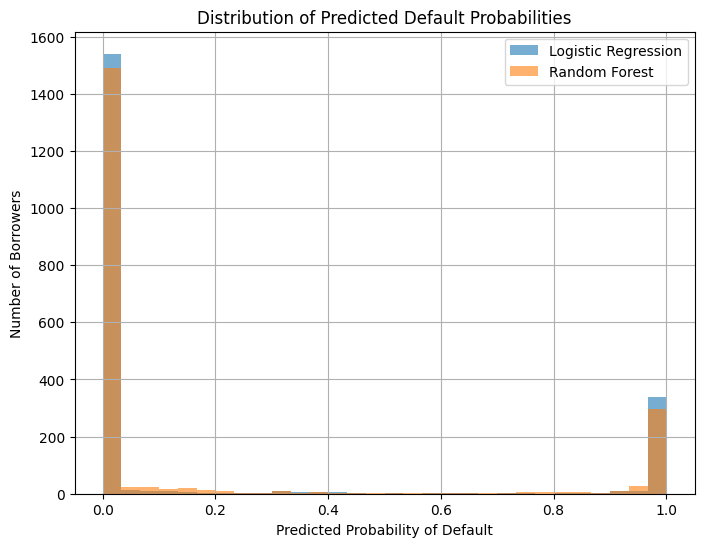

In [29]:
plt.figure(figsize=(8, 6))

plt.hist(logistic_pd, bins=30, alpha=0.6, label="Logistic Regression")
plt.hist(random_forest_pd, bins=30, alpha=0.6, label="Random Forest")

plt.xlabel("Predicted Probability of Default")
plt.ylabel("Number of Borrowers")
plt.title("Distribution of Predicted Default Probabilities")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
pd_distribution = pd.DataFrame({
    "actual_default": y_test.values,
    "logistic_pd": logistic_pd,
    "random_forest_pd": random_forest_pd
})

pd_distribution.groupby("actual_default")[["logistic_pd", "random_forest_pd"]].mean()

,logistic_pd,random_forest_pd
actual_default,,
0,0.014455,0.018216
1,0.988759,0.966514


The average predicted probability of default is much lower for borrowers who did not default than for borrowers who did default. This suggests that both models are assigning higher risk scores to genuinely riskier borrowers, which is desirable for expected loss estimation.

### 7.4 Random Forest Feature Importance

Random Forest models allow us to inspect feature importance. This indicates which borrower characteristics contribute most to the model's predictions.

Feature importance does not imply causality, but it helps understand which variables the model relies on most when estimating probability of default.

In [31]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
0,credit_lines_outstanding,0.559888
2,total_debt_outstanding,0.324951
4,years_employed,0.043731
5,fico_score,0.036886
3,income,0.022347
1,loan_amt_outstanding,0.012197


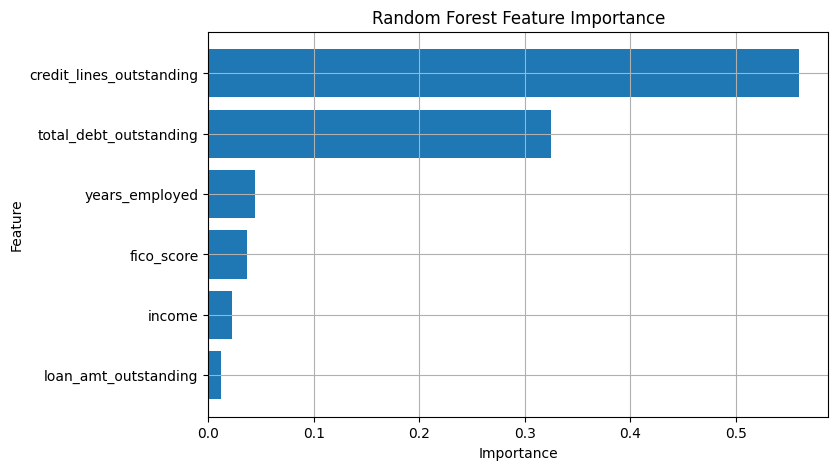

In [32]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

The feature importance ranking shows which borrower characteristics are most relevant for the Random Forest model. Variables with higher importance have a stronger influence on the model's probability of default estimates.

This provides a useful interpretability check before using the model to calculate expected loss.

## 8. Final Model Selection

After comparing the Logistic Regression and Random Forest models, the Random Forest model is selected as the final probability of default model.

The Logistic Regression model provides a useful interpretable baseline, but the Random Forest model is more flexible because it can capture non-linear relationships and interactions between borrower characteristics.

The final model will therefore use the Random Forest predicted probability as the borrower's estimated probability of default.

In [33]:
RECOVERY_RATE = 0.10
LGD = 1 - RECOVERY_RATE

In [34]:
def estimate_expected_loss(
    credit_lines_outstanding,
    loan_amt_outstanding,
    total_debt_outstanding,
    income,
    years_employed,
    fico_score,
    model = random_forest_model
):
    borrower = pd.DataFrame({
        "credit_lines_outstanding": [credit_lines_outstanding],
        "loan_amt_outstanding": [loan_amt_outstanding],
        "total_debt_outstanding": [total_debt_outstanding],
        "income": [income],
        "years_employed": [years_employed],
        "fico_score": [fico_score]
    })

    probability_of_default = model.predict_proba(borrower)[0, 1]

    ead = loan_amt_outstanding
    expected_loss = probability_of_default * LGD * ead

    return {
        "probability_of_default": probability_of_default,
        "loss_given_default": LGD,
        "exposure_at_default": ead,
        "expected_loss": expected_loss
    }

In [36]:
sample_borrower = X_test.iloc[0]

estimate_expected_loss(
    credit_lines_outstanding = sample_borrower["credit_lines_outstanding"],
    loan_amt_outstanding = sample_borrower["loan_amt_outstanding"],
    total_debt_outstanding = sample_borrower["total_debt_outstanding"],
    income = sample_borrower["income"],
    years_employed = sample_borrower["years_employed"],
    fico_score = sample_borrower["fico_score"]
)

{'probability_of_default': np.float64(0.0),
 'loss_given_default': 0.9,
 'exposure_at_default': np.float64(3751.658863),
 'expected_loss': np.float64(0.0)}

The function takes borrower-level loan characteristics as inputs, estimates the probability of default using the selected Random Forest model, and then calculates expected loss using:

$$
Expected\ Loss = PD \times LGD \times EAD
$$

In this implementation, the exposure at default is assumed to be the outstanding loan amount, and the loss given default is 90% because the recovery rate is 10%.

## 9. Sample Predictions

To test the expected loss function, we evaluate a few sample borrowers with different risk profiles.

This helps check whether the model assigns lower probability of default to stronger borrowers and higher probability of default to riskier borrowers.

In [37]:
low_risk_borrower = estimate_expected_loss(
    credit_lines_outstanding=1,
    loan_amt_outstanding=5000,
    total_debt_outstanding=8000,
    income=90000,
    years_employed=7,
    fico_score=760
)

medium_risk_borrower = estimate_expected_loss(
    credit_lines_outstanding=3,
    loan_amt_outstanding=15000,
    total_debt_outstanding=30000,
    income=60000,
    years_employed=4,
    fico_score=650
)

high_risk_borrower = estimate_expected_loss(
    credit_lines_outstanding=5,
    loan_amt_outstanding=30000,
    total_debt_outstanding=70000,
    income=40000,
    years_employed=1,
    fico_score=540
)

In [38]:
sample_results = pd.DataFrame([
    {
        "profile": "Low Risk",
        **low_risk_borrower
    },
    {
        "profile": "Medium Risk",
        **medium_risk_borrower
    },
    {
        "profile": "High Risk",
        **high_risk_borrower
    }
])

sample_results

,profile,probability_of_default,loss_given_default,exposure_at_default,expected_loss
0,Low Risk,0.000000,0.9,5000,0.000000
1,Medium Risk,0.492386,0.9,15000,6647.208436
2,High Risk,0.991303,0.9,30000,26765.188947


The sample predictions show how the model translates borrower characteristics into probability of default and expected loss.

Borrowers with stronger credit profiles, such as higher FICO scores, higher income, lower debt, and longer employment history, are expected to receive lower estimated probabilities of default. Riskier borrowers are expected to receive higher probabilities of default and therefore higher expected losses.

## 10. Limitations and Next Steps

This prototype estimates probability of default using borrower-level financial characteristics and then converts the predicted probability into expected loss.

The model provides a practical framework for credit risk estimation because it links machine learning predictions with the standard expected loss formula:

$$
Expected\ Loss = PD \times LGD \times EAD
$$

However, the model has several limitations. First, the dataset contains a limited set of borrower characteristics and does not include broader macroeconomic variables such as interest rates, unemployment, inflation, or economic cycle indicators. These factors can have a significant impact on default risk.

Second, the loss given default is assumed to be fixed at 90%, based on a 10% recovery rate. In practice, recovery rates can vary depending on collateral, seniority, loan type, and market conditions.

Third, the model is trained and evaluated on historical data. Its future performance depends on whether the relationships observed in the historical dataset remain stable over time.

Future improvements could include adding more borrower-level and macroeconomic variables, testing probability calibration methods, monitoring model performance over time, and validating the model under different economic scenarios.

Overall, the model provides a clear and interpretable starting point for estimating probability of default and expected loss before further validation and production deployment.